<a href="https://colab.research.google.com/github/Deeparam06-devcodes/Deeparepo/blob/main/Final_Project_%E2%80%93_Fashion_MNIST_Classification_using_PyTorch_CNN_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_data = torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Train:", len(train_data))
print("Test:", len(test_data))

100%|██████████| 26.4M/26.4M [00:01<00:00, 22.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 343kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.31MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.9MB/s]

Train: 60000
Test: 10000


In [3]:
train_loader = torch.utils.data.DataLoader(
    train_data,
    batch_size=128,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_data,
    batch_size=128,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 469
Test batches: 79


In [4]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 10)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = CNN().to(device)

print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=10, bias=True)
  )
)


In [5]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss:", criterion)
print("Optimizer:", optimizer.__class__.__name__)

Loss: CrossEntropyLoss()
Optimizer: Adam


In [6]:
train_losses = []

for epoch in range(2):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1}/2 - Loss: {avg_loss:.4f}")

Epoch 1/2 - Loss: 0.5523
Epoch 2/2 - Loss: 0.3561


In [7]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 87.78%


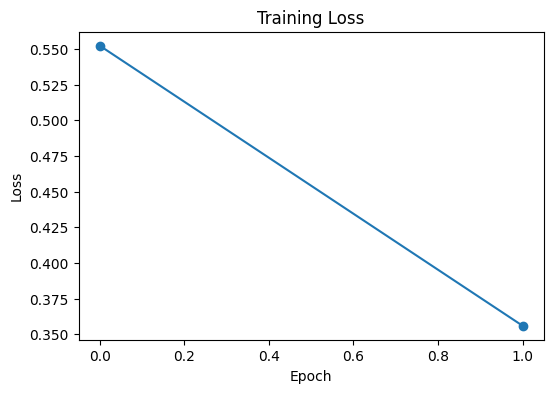

In [8]:
plt.figure(figsize=(6,4))
plt.plot(train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [9]:
torch.save(model.state_dict(), "fashion_mnist_cnn.pth")

print("Model saved successfully!")

Model saved successfully!


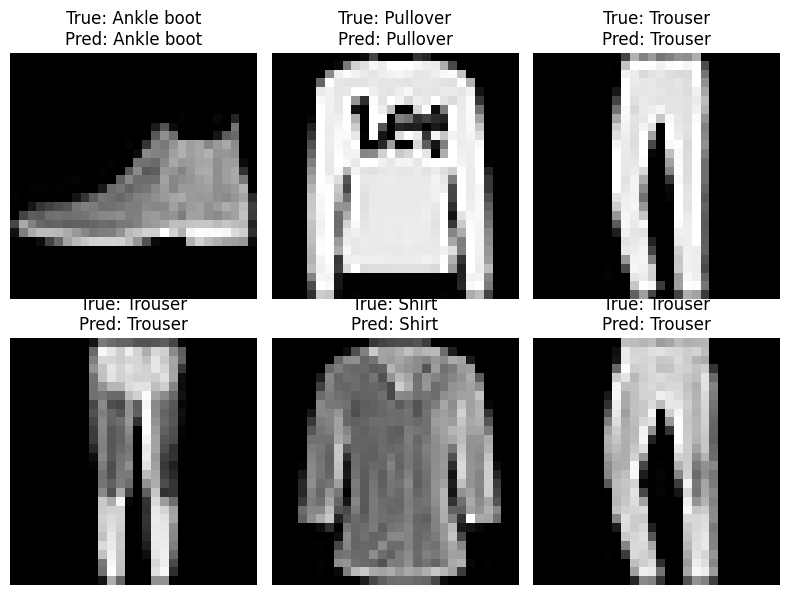

In [10]:
classes = train_data.classes

images, labels = next(iter(test_loader))

model.eval()
with torch.no_grad():
    outputs = model(images.to(device))
    predictions = outputs.argmax(dim=1).cpu()

plt.figure(figsize=(8, 6))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"True: {classes[labels[i]]}\nPred: {classes[predictions[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        predictions = outputs.argmax(dim=1)

        total += labels.size(0)
        correct += (predictions.cpu() == labels).sum().item()

final_accuracy = 100 * correct / total

print(f"Final Test Accuracy: {final_accuracy:.2f}%")

Final Test Accuracy: 87.78%


In [12]:
torch.save(model.state_dict(), "fashion_mnist_cnn.pth")
print("Final model saved successfully!")

Final model saved successfully!


In [13]:
class_correct = [0] * 10
class_total = [0] * 10

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        predictions = outputs.argmax(1).cpu()

        for i in range(len(labels)):
            label = labels[i]
            class_total[label] += 1
            class_correct[label] += (predictions[i] == label).item()

for i in range(10):
    acc = 100 * class_correct[i] / class_total[i]
    print(f"{train_data.classes[i]}: {acc:.2f}%")

T-shirt/top: 86.10%
Trouser: 96.50%
Pullover: 81.70%
Dress: 83.90%
Coat: 85.90%
Sandal: 95.40%
Shirt: 60.40%
Sneaker: 95.30%
Bag: 97.20%
Ankle boot: 95.40%


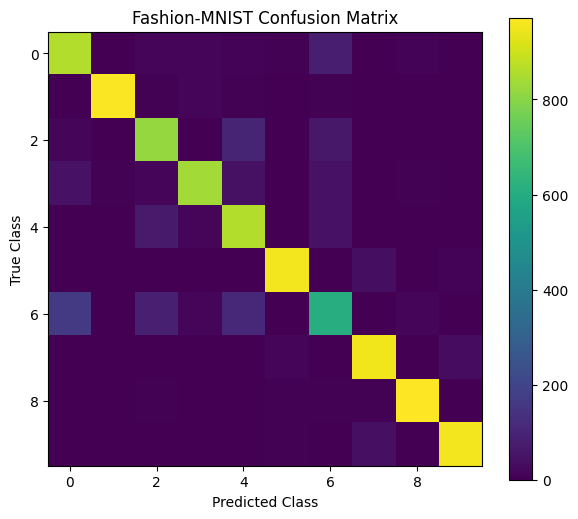

In [14]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds) if 'all_labels' in globals() else None

if cm is None:
    all_labels, all_preds = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images.to(device))
            preds = outputs.argmax(1).cpu()
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.numpy())

    cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 6))
plt.imshow(cm)
plt.title("Fashion-MNIST Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.colorbar()
plt.show()

In [15]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_preds,
    target_names=train_data.classes
))

              precision    recall  f1-score   support

 T-shirt/top       0.79      0.86      0.82      1000
     Trouser       0.99      0.96      0.98      1000
    Pullover       0.81      0.82      0.81      1000
       Dress       0.92      0.84      0.88      1000
        Coat       0.76      0.86      0.81      1000
      Sandal       0.97      0.95      0.96      1000
       Shirt       0.70      0.60      0.65      1000
     Sneaker       0.92      0.95      0.94      1000
         Bag       0.96      0.97      0.97      1000
  Ankle boot       0.96      0.95      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [16]:
print("===== Fashion-MNIST CNN Project Summary =====")
print(f"Model: CNN")
print(f"Test Accuracy: {final_accuracy:.2f}%")
print("Dataset: Fashion-MNIST")
print("Number of Classes: 10")
print("Framework: PyTorch")
print("Model saved as: fashion_mnist_cnn.pth")
print("=============================================")

===== Fashion-MNIST CNN Project Summary =====
Model: CNN
Test Accuracy: 87.78%
Dataset: Fashion-MNIST
Number of Classes: 10
Framework: PyTorch
Model saved as: fashion_mnist_cnn.pth
